# TransUNet for Medical Image Classification
## Dataset: Brain Tumor Classification (MRI)

This notebook adapts **TransUNet** for **multi-class classification** of brain MRI scans
across four tumor categories. MRI is a completely different imaging modality from chest X-ray
and dermoscopy, demonstrating that the adapted TransUNet generalises **across modalities**.
This is also the only multi-class experiment in this study, showing the architecture
is not limited to binary classification tasks.

### Dataset
- Source: Brain Tumor MRI Dataset — Masoud Nickparvar (Kaggle)
- Link: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
- Classes: Glioma · Meningioma · No Tumor · Pituitary (4 classes)
- Size: 7,200 images (1,800 per class, perfectly balanced)
- Modality: MRI (T1-weighted)

### Note on Dataset Selection
An earlier smaller dataset of 253 images by Navoneel Chakrabarty was initially
identified but deemed too small for reliable training and evaluation. We instead
used this larger dataset of 7,200 images which provides sufficient samples per
class for meaningful multi-class classification results.

### Key difference from other notebooks
This is a 4-class classification task rather than binary. The evaluation cell
uses multi-class AUC-ROC (one-vs-rest, weighted average) and the ROC plot
displays one curve per class. The dataset comes pre-split into Training and
Testing folders which are merged and re-split 80/10/10 using the same random
seed as all other experiments for consistency.

## Section 1: Setup & Installs

In [ ]:
# connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install kagglehub
!pip install -q kagglehub

import kagglehub
import shutil


# Download the dataset (goes to a Colab cache folder first)
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print(f"Downloaded to cache: {path}")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Downloaded to cache: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import shutil
import os

DEST = '/content/drive/MyDrive/TransUNet_Classification/Datasets/brain_tumor_dataset'
os.makedirs(DEST, exist_ok=True)

shutil.copytree(path, DEST, dirs_exist_ok=True)
print(os.listdir(DEST))

['Training', 'Testing']


In [ ]:
import os
import shutil

SOURCE = '/content/drive/MyDrive/TransUNet_Classification/Datasets/brain_tumor_dataset'
DEST   = '/content/drive/MyDrive/TransUNet_Classification/Datasets/BrainTumor_Merged'

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for cls in classes:
    os.makedirs(os.path.join(DEST, cls), exist_ok=True)

for split in ['Training', 'Testing']:
    for cls in classes:
        src_folder = os.path.join(SOURCE, split, cls)
        dst_folder = os.path.join(DEST, cls)

        if not os.path.exists(src_folder):
            print(f"WARNING: {src_folder} not found — check folder names")
            continue

        for img_file in os.listdir(src_folder):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                src_path = os.path.join(src_folder, img_file)
                dst_path = os.path.join(dst_folder, f"{split}_{img_file}")
                shutil.copy2(src_path, dst_path)

# Confirm counts
print("\nMerged dataset:")
for cls in classes:
    count = len(os.listdir(os.path.join(DEST, cls)))
    print(f"  {cls}: {count} images")


Merged dataset:
  glioma: 1800 images
  meningioma: 1800 images
  notumor: 1800 images
  pituitary: 1800 images


In [ ]:
# Install required packages
!pip install -q timm ml_collections

# Clone TransUNet repo (provides the ViT + hybrid encoder)
!git clone https://github.com/Beckschen/TransUNet.git

print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.6 MB/s eta 0:00:00
Cloning into 'TransUNet'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 128 (delta 71), reused 48 (delta 48), pack-reused 40 (from 1)
Receiving objects: 100% (128/128), 47.00 KiB | 908.00 KiB/s, done.
Resolving deltas: 100% (71/71), done.
Done!


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# Add TransUNet to path
sys.path.insert(0, '/content/TransUNet')

from networks.vit_seg_modeling import VisionTransformer as ViT_seg
from networks.vit_seg_modeling import CONFIGS as VIT_CONFIGS

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Section 2: Configuration
**Only change this cell when adapting to a new dataset.**

In [ ]:
DATASET_NAME  = 'BrainTumor'
DATASET_PATH  = '/content/drive/MyDrive/TransUNet_Classification/Datasets/BrainTumor_Merged'
SAVE_DIR      = '/content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor'
CLASS_NAMES   = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES   = 4
DATASET_TYPE  = 'folder'

CSV_PATH  = None
IMG_DIR   = None
IMG_COL   = None
LABEL_COL = None

IMG_SIZE       = 224
BATCH_SIZE     = 32
NUM_EPOCHS     = 30
LEARNING_RATE  = 1e-4
RANDOM_SEED    = 42

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, 'metric_images'), exist_ok=True)

TRANSUNET_WEIGHTS = os.path.join(SAVE_DIR, f'transunet_{DATASET_NAME.lower()}_best.pth')
DENSENET_WEIGHTS  = os.path.join(SAVE_DIR, f'densenet_{DATASET_NAME.lower()}_best.pth')

print(f'Dataset  : {DATASET_NAME}')
print(f'Classes  : {CLASS_NAMES}')
print(f'Device   : {device}')

Dataset  : BrainTumor
Classes  : ['glioma', 'meningioma', 'notumor', 'pituitary']
Device   : cuda


## Section 3: Dataset Loading

In [ ]:
# ── Folder-based dataset (TB, Pneumonia, Brain Tumor) ──────────────────────
class FolderDataset(Dataset):
    """
    Loads images from a directory where each class has its own subfolder.
    Expected structure:
        root_dir/
            class_a/  img1.jpg  img2.png ...
            class_b/  img1.jpg  img2.png ...
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        for cls in self.classes:
            cls_folder = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_folder):
                continue
            for img_file in os.listdir(cls_folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(cls_folder, img_file), self.class_to_idx[cls]))

        print(f'Dataset loaded: {len(self.samples)} images | Classes: {self.class_to_idx}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        return image, label


# ── CSV-based dataset (ISIC Melanoma) ──────────────────────────────────────
class CSVDataset(Dataset):
    """
    Loads images from a directory using a CSV manifest.
    Used for ISIC-style datasets where labels live in a CSV, not folder names.

    CSV must have at minimum:
        - img_col  : image filename (without extension, e.g. 'ISIC_0000000')
        - label_col: integer label (0 or 1)
    """
    def __init__(self, csv_path, img_dir, img_col, label_col, img_ext='.jpg', transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.img_col = img_col
        self.label_col = label_col
        self.img_ext = img_ext
        self.transform = transform
        print(f'CSV dataset loaded: {len(self.df)} images')
        print(f'Label distribution:\n{self.df[label_col].value_counts()}')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, str(row[self.img_col]) + self.img_ext)
        image = Image.open(img_path).convert('RGB')
        label = int(row[self.label_col])
        if self.transform:
            image = self.transform(image)
        return image, label


# ── Wrapper to apply different transforms to each split ────────────────────
class TransformSubset(Dataset):
    """Wraps a Subset and applies a transform to it."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


print('Dataset classes defined!')

Dataset classes defined!


In [ ]:
# Load the full dataset (no transforms yet — applied per split below)
if DATASET_TYPE == 'folder':
    full_dataset = FolderDataset(root_dir=DATASET_PATH, transform=None)
elif DATASET_TYPE == 'csv':
    full_dataset = CSVDataset(
        csv_path=CSV_PATH, img_dir=IMG_DIR,
        img_col=IMG_COL, label_col=LABEL_COL, transform=None
    )

# Explore class distribution
if DATASET_TYPE == 'folder':
    print('\nClass counts:')
    for cls in full_dataset.classes:
        cls_path = os.path.join(DATASET_PATH, cls)
        print(f'  {cls}: {len(os.listdir(cls_path))} images')

Dataset loaded: 7200 images | Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Class counts:
  glioma: 1800 images
  meningioma: 1800 images
  notumor: 1800 images
  pituitary: 1800 images


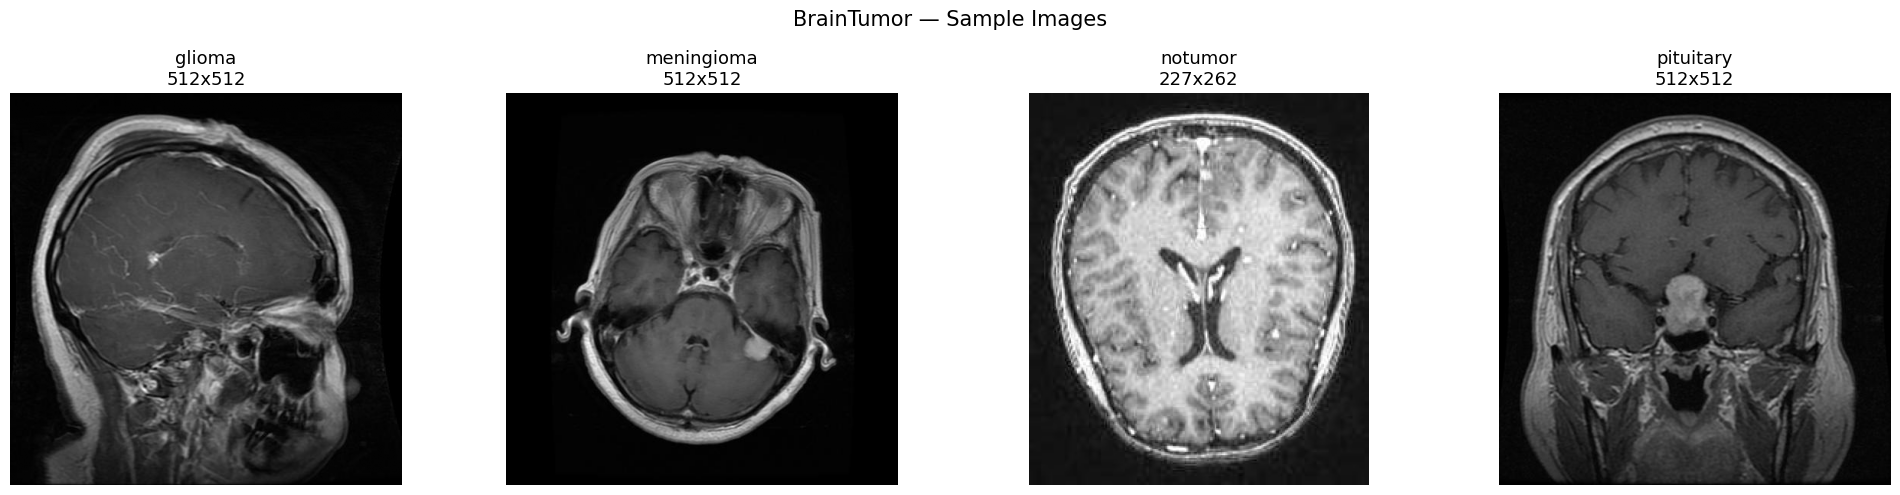

In [ ]:
# Visualize one sample from each class
if DATASET_TYPE == 'folder':
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 5))
    if NUM_CLASSES == 2:
        axes = [axes] if NUM_CLASSES == 1 else axes
    for idx, cls in enumerate(full_dataset.classes):
        cls_path = os.path.join(DATASET_PATH, cls)
        sample_img = Image.open(os.path.join(cls_path, os.listdir(cls_path)[0]))
        axes[idx].imshow(sample_img, cmap='gray' if sample_img.mode == 'L' else None)
        axes[idx].set_title(f'{cls}\n{sample_img.size[0]}x{sample_img.size[1]}', fontsize=13)
        axes[idx].axis('off')
    plt.suptitle(f'{DATASET_NAME} — Sample Images', fontsize=15)
    plt.tight_layout()
    plt.show()

## Section 4: Preprocessing & Data Splits

In [ ]:
# Training transforms — with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation / Test transforms — no augmentation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split sizes: 80 / 10 / 10
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size   = int(0.1 * total_size)
test_size  = total_size - train_size - val_size

print(f'Total   : {total_size}')
print(f'Train   : {train_size}')
print(f'Val     : {val_size}')
print(f'Test    : {test_size}')

# Split with fixed seed for reproducibility
train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

# Attach transforms
train_dataset = TransformSubset(train_subset, transform=train_transforms)
val_dataset   = TransformSubset(val_subset,   transform=val_test_transforms)
test_dataset  = TransformSubset(test_subset,  transform=val_test_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Sanity check
images, labels = next(iter(train_loader))
print(f'\nBatch shape : {images.shape}')  # [32, 3, 224, 224]
print(f'Labels      : {labels[:8].tolist()}')

Total   : 7200
Train   : 5760
Val     : 720
Test    : 720

Train batches : 180
Val batches   : 23
Test batches  : 23

Batch shape : torch.Size([32, 3, 224, 224])
Labels      : [1, 3, 3, 0, 3, 3, 3, 2]


## Section 5: Model Architectures
### 5a: TransUNet Classifier (the novel contribution)

Standard TransUNet: ResNet50 encoder → ViT transformer → UNet decoder → segmentation output  
**Our adaptation:** ResNet50 encoder → ViT transformer → **Global Average Pooling → Classification head**

The decoder is discarded entirely. We pool over all patch token representations
(mean across the sequence dimension) to get a single feature vector, then classify.

In [ ]:
class TransUNetClassifier(nn.Module):
    """
    TransUNet adapted for image classification.

    Architecture change vs original TransUNet:
    - Decoder (upsampling + segmentation head) is replaced by:
        1. Global Average Pooling over transformer patch tokens
        2. LayerNorm + Dropout + Linear classification head

    This allows the model to be used as a general-purpose classifier
    without any task-specific pretraining.

    Args:
        config      : TransUNet config (from VIT_CONFIGS)
        num_classes : number of output classes
        img_size    : input image size (default 224)
    """
    def __init__(self, config, num_classes=2, img_size=224):
        super(TransUNetClassifier, self).__init__()

        # Load the full TransUNet (we only use the encoder + transformer)
        self.transunet = ViT_seg(config, img_size=img_size, num_classes=num_classes)

        hidden_size = config.hidden_size  # 768 for ViT-B_16

        # Classification head replaces the segmentation decoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),     # stabilizes transformer outputs
            nn.Dropout(p=0.5),             # regularization
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # Forward through ResNet encoder + ViT transformer
        # x: [batch, 3, H, W]
        x, attn_weights, features = self.transunet.transformer(x)
        # x: [batch, num_patches, hidden_size]

        # Global average pooling over patch tokens → [batch, hidden_size]
        # Alternative: use x[:, 0, :] if CLS token is available
        x = x.mean(dim=1)

        # Classify
        return self.classifier(x)


def build_transunet(num_classes=2, img_size=224):
    """Build and return a TransUNetClassifier with standard R50-ViT-B_16 config."""
    config = VIT_CONFIGS['R50-ViT-B_16']
    config.n_classes = num_classes
    config.n_skip = 3
    config.patches.grid = (img_size // 16, img_size // 16)  # e.g. 14x14 for 224
    config.pretrained_path = None  # training from scratch
    model = TransUNetClassifier(config, num_classes=num_classes, img_size=img_size)
    return model


print('TransUNetClassifier defined!')

TransUNetClassifier defined!


### 5b: DenseNet-121 Baseline

In [ ]:
class DenseNetClassifier(nn.Module):
    """
    DenseNet-121 fine-tuned for binary/multi-class classification.
    Uses ImageNet pretrained weights — serves as the strong baseline.

    Args:
        num_classes : number of output classes
        pretrained  : use ImageNet pretrained weights (default True)
    """
    def __init__(self, num_classes=2, pretrained=True):
        super(DenseNetClassifier, self).__init__()
        self.model = models.densenet121(pretrained=pretrained)
        in_features = self.model.classifier.in_features  # 1024
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


print('DenseNetClassifier defined!')

DenseNetClassifier defined!


## Section 6: Training Utilities

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Run one full training epoch. Returns (loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total * 100


def validate(model, loader, criterion):
    """Run validation (no gradient updates). Returns (loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total * 100


def run_training(model, model_name, save_path, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """
    Full training loop with early stopping via best-val-loss tracking.

    Returns:
        history (dict): train/val loss and accuracy per epoch
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')

    print(f'\n{"="*50}')
    print(f'Training: {model_name}')
    print(f'{"="*50}')

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc     = validate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch [{epoch+1:02d}/{num_epochs}] | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%', end='')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(' ← best saved', end='')
        print()

    # Save history CSV
    hist_df = pd.DataFrame(history)
    hist_path = os.path.join(SAVE_DIR, f'{model_name.lower().replace(" ","_")}_history.csv')
    hist_df.to_csv(hist_path, index=False)

    print(f'\nTraining complete! Best val loss: {best_val_loss:.4f}')
    print(f'Weights saved to  : {save_path}')
    print(f'History saved to  : {hist_path}')
    return history


print('Training utilities ready!')

Training utilities ready!


## Section 7: Evaluation Utilities

In [ ]:
#


def evaluate_model(model, weights_path, model_name):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'Testing {model_name}'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())   # full probability vector now

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)   # shape: [n_samples, n_classes]

    acc = accuracy_score(all_labels, all_preds) * 100
    f1  = f1_score(all_labels, all_preds, average='weighted') * 100

    # AUC-ROC: binary vs multi-class handled automatically
    if NUM_CLASSES == 2:
        auc_roc = roc_auc_score(all_labels, all_probs[:, 1]) * 100
    else:
        auc_roc = roc_auc_score(
            all_labels, all_probs,
            multi_class='ovr',
            average='weighted'
        ) * 100

    print(f'\n{"="*50}')
    print(f'  {model_name} — {DATASET_NAME} Test Results')
    print(f'{"="*50}')
    print(f'  Accuracy : {acc:.2f}%')
    print(f'  F1 Score : {f1:.2f}%')
    print(f'  AUC-ROC  : {auc_roc:.2f}%')
    print(f'{"="*50}')
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    return {
        'model_name': model_name,
        'accuracy':   acc,
        'f1':         f1,
        'auc_roc':    auc_roc,
        'preds':      all_preds,
        'labels':     all_labels,
        'probs':      all_probs
    }

## Section 8: Visualization Utilities

In [ ]:
def plot_training_history(history, model_name):
    """Plot and save loss + accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
    axes[0].plot(history['val_loss'],   label='Val Loss',   color='coral',     linewidth=2)
    axes[0].set_title('Loss Over Epochs', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train Accuracy', color='steelblue', linewidth=2)
    axes[1].plot(history['val_acc'],   label='Val Accuracy',   color='coral',     linewidth=2)
    axes[1].set_title('Accuracy Over Epochs', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} — {DATASET_NAME} Training History', fontsize=15)
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images',
                             f'{model_name.lower().replace(" ","_")}_training_history.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_confusion_matrix(results):
    """Plot and save confusion matrix."""
    cm = confusion_matrix(results['labels'], results['preds'])
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{results['model_name']} — {DATASET_NAME} Confusion Matrix", fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images',
                             f"{results['model_name'].lower().replace(' ','_')}_confusion_matrix.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_roc_curve(results):
    """One ROC curve per class (one-vs-rest) for multi-class."""
    from sklearn.preprocessing import label_binarize

    if NUM_CLASSES == 2:
        # Original binary logic
        fpr, tpr, _ = roc_curve(results['labels'], results['probs'][:, 1])
        plt.figure(figsize=(7, 6))
        plt.plot(fpr, tpr, color='steelblue', linewidth=2,
                 label=f"AUC = {results['auc_roc']:.2f}%")
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.title(f"{results['model_name']} — {DATASET_NAME} ROC Curve")
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        # One curve per class
        labels_bin = label_binarize(results['labels'], classes=list(range(NUM_CLASSES)))
        colors = ['steelblue', 'coral', 'green', 'purple']

        plt.figure(figsize=(9, 7))
        for i, cls_name in enumerate(CLASS_NAMES):
            fpr, tpr, _ = roc_curve(labels_bin[:, i], results['probs'][:, i])
            auc_i = roc_auc_score(labels_bin[:, i], results['probs'][:, i])
            plt.plot(fpr, tpr, color=colors[i], linewidth=2,
                     label=f"{cls_name} (AUC = {auc_i:.3f})")

        plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
        plt.title(f"{results['model_name']} — {DATASET_NAME} ROC Curves (One vs Rest)")
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, 'metric_images',
                             f"{results['model_name'].lower().replace(' ','_')}_roc_curve.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_comparison(results_list):
    """Bar chart comparing models side by side on all three metrics."""
    model_names = [r['model_name'] for r in results_list]
    metrics = ['accuracy', 'f1', 'auc_roc']
    metric_labels = ['Accuracy (%)', 'F1 Score (%)', 'AUC-ROC (%)']
    colors = ['steelblue', 'coral']

    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, result in enumerate(results_list):
        values = [result[m] for m in metrics]
        bars = ax.bar(x + i * width, values, width, label=result['model_name'], color=colors[i])
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
                    f'{val:.2f}%', ha='center', va='top', fontsize=10, color='white', fontweight='bold')

    ax.set_ylim([85, 102])
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(metric_labels, fontsize=12)
    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title(f'Model Comparison — {DATASET_NAME}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images', 'comparison_chart.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


print('Visualization utilities ready!')

Visualization utilities ready!


## Section 9: Train TransUNet

In [ ]:
# Build the model
transunet_model = build_transunet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)

total_params = sum(p.numel() for p in transunet_model.parameters())
print(f'TransUNet total parameters: {total_params:,}')
print('Note: Training from scratch — no pretrained weights')

TransUNet total parameters: 105,280,968
Note: Training from scratch — no pretrained weights


In [ ]:
transunet_history = run_training(
    model=transunet_model,
    model_name='TransUNet',
    save_path=TRANSUNET_WEIGHTS,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)


Training: TransUNet


Epoch [01/30] | Train Loss: 1.2923 Acc: 40.62% | Val Loss: 0.8656 Acc: 62.36% ← best saved


Epoch [02/30] | Train Loss: 0.8514 Acc: 61.27% | Val Loss: 0.7153 Acc: 65.28% ← best saved


Epoch [03/30] | Train Loss: 0.7019 Acc: 67.07% | Val Loss: 0.6568 Acc: 70.42% ← best saved


Epoch [04/30] | Train Loss: 0.6454 Acc: 68.94% | Val Loss: 0.6057 Acc: 71.11% ← best saved


...

Epoch [26/30] | Train Loss: 0.1493 Acc: 95.23% | Val Loss: 0.1777 Acc: 94.44%


Epoch [27/30] | Train Loss: 0.1531 Acc: 94.77% | Val Loss: 0.1774 Acc: 94.17%


Epoch [28/30] | Train Loss: 0.1708 Acc: 94.36% | Val Loss: 0.1342 Acc: 94.86%


Epoch [29/30] | Train Loss: 0.0947 Acc: 97.01% | Val Loss: 0.0668 Acc: 97.22% ← best saved


Epoch [30/30] | Train Loss: 0.0792 Acc: 97.47% | Val Loss: 0.0854 Acc: 96.53%

Training complete! Best val loss: 0.0668
Weights saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/transunet_braintumor_best.pth
History saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/transunet_history.csv


## Section 10: Train DenseNet-121 (Baseline)

In [ ]:
densenet_model = DenseNetClassifier(num_classes=NUM_CLASSES, pretrained=True).to(device)

total_params = sum(p.numel() for p in densenet_model.parameters())
print(f'DenseNet-121 total parameters: {total_params:,}')
print('Using ImageNet pretrained weights')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 162MB/s]

DenseNet-121 total parameters: 6,957,956
Using ImageNet pretrained weights


In [ ]:
densenet_history = run_training(
    model=densenet_model,
    model_name='DenseNet-121',
    save_path=DENSENET_WEIGHTS,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)


Training: DenseNet-121


Epoch [01/30] | Train Loss: 0.3707 Acc: 86.88% | Val Loss: 0.1039 Acc: 96.53% ← best saved


Epoch [02/30] | Train Loss: 0.1340 Acc: 96.04% | Val Loss: 0.0605 Acc: 98.06% ← best saved


Epoch [03/30] | Train Loss: 0.0929 Acc: 97.24% | Val Loss: 0.0504 Acc: 98.75% ← best saved


Epoch [04/30] | Train Loss: 0.0671 Acc: 97.95% | Val Loss: 0.0761 Acc: 97.64%


...

Epoch [26/30] | Train Loss: 0.0041 Acc: 99.86% | Val Loss: 0.0078 Acc: 99.86%


Epoch [27/30] | Train Loss: 0.0050 Acc: 99.76% | Val Loss: 0.0058 Acc: 99.72% ← best saved


Epoch [28/30] | Train Loss: 0.0041 Acc: 99.88% | Val Loss: 0.0040 Acc: 99.72% ← best saved


Epoch [29/30] | Train Loss: 0.0050 Acc: 99.77% | Val Loss: 0.0061 Acc: 99.72%


Epoch [30/30] | Train Loss: 0.0041 Acc: 99.83% | Val Loss: 0.0054 Acc: 99.72%

Training complete! Best val loss: 0.0040
Weights saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/densenet_braintumor_best.pth
History saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/densenet-121_history.csv


## Section 11: Evaluate & Visualize

In [ ]:
# Evaluate both models
transunet_results = evaluate_model(transunet_model, TRANSUNET_WEIGHTS, 'TransUNet')
densenet_results  = evaluate_model(densenet_model,  DENSENET_WEIGHTS,  'DenseNet-121')

Testing TransUNet: 100%|██████████| 23/23 [00:11<00:00,  1.96it/s]



  TransUNet — BrainTumor Test Results
  Accuracy : 95.56%
  F1 Score : 95.56%
  AUC-ROC  : 99.46%
              precision    recall  f1-score   support

      glioma       0.94      0.94      0.94       197
  meningioma       0.97      0.93      0.95       164
     notumor       0.93      0.97      0.95       172
   pituitary       0.99      0.98      0.98       187

    accuracy                           0.96       720
   macro avg       0.96      0.96      0.96       720
weighted avg       0.96      0.96      0.96       720



Testing DenseNet-121: 100%|██████████| 23/23 [00:05<00:00,  4.47it/s]


  DenseNet-121 — BrainTumor Test Results
  Accuracy : 98.89%
  F1 Score : 98.89%
  AUC-ROC  : 99.98%
              precision    recall  f1-score   support

      glioma       0.98      0.99      0.98       197
  meningioma       0.99      0.98      0.98       164
     notumor       0.98      0.99      0.99       172
   pituitary       1.00      0.99      1.00       187

    accuracy                           0.99       720
   macro avg       0.99      0.99      0.99       720
weighted avg       0.99      0.99      0.99       720



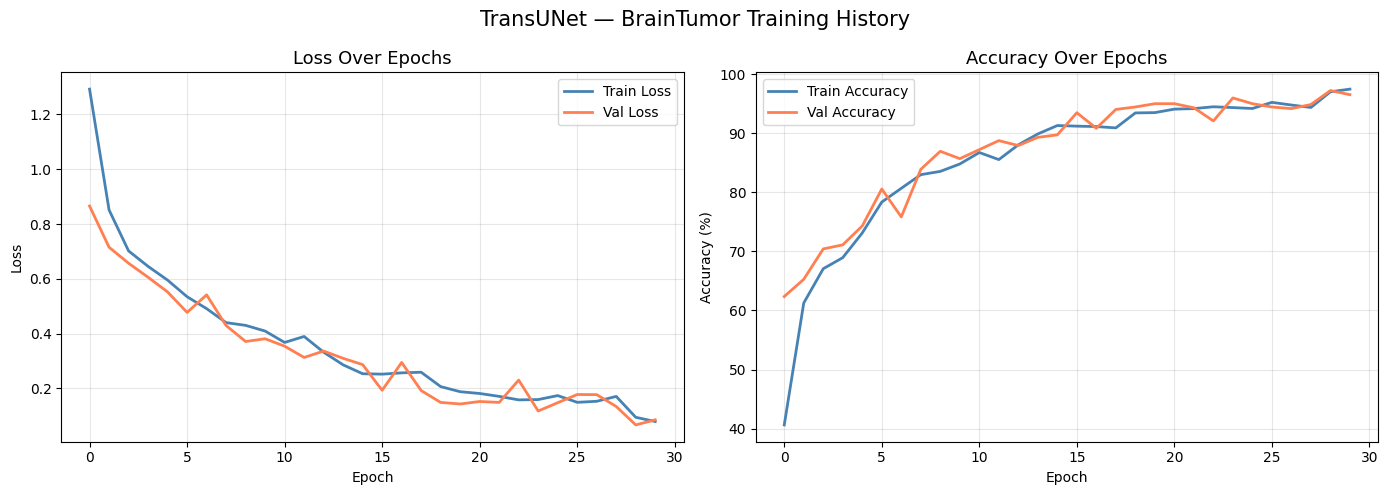

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/metric_images/transunet_training_history.png


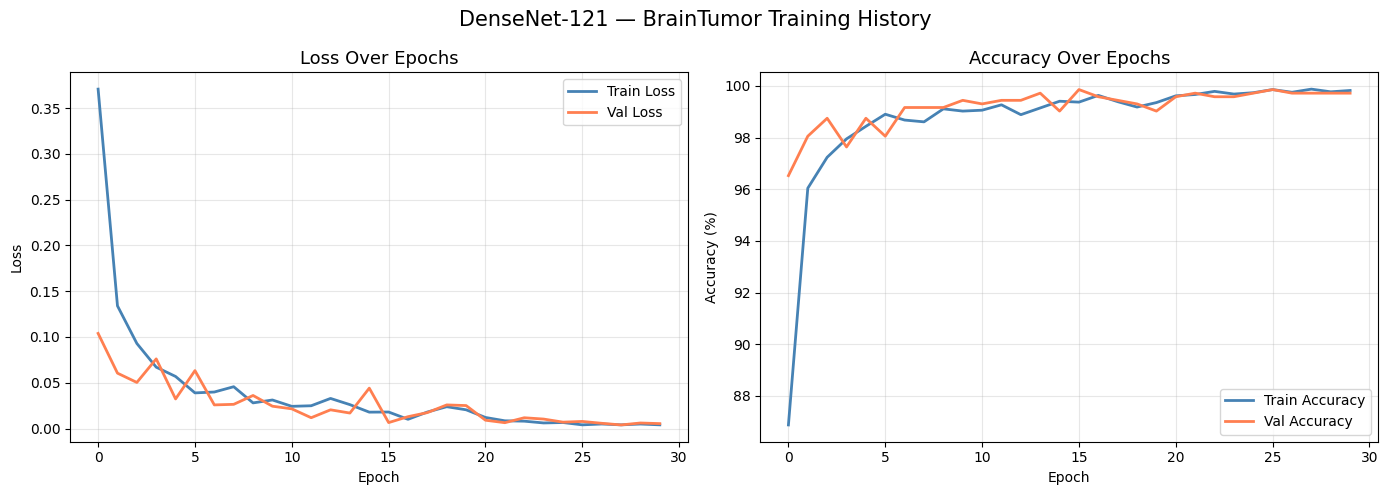

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/metric_images/densenet-121_training_history.png


In [ ]:
# Training curves
plot_training_history(transunet_history, 'TransUNet')
plot_training_history(densenet_history,  'DenseNet-121')

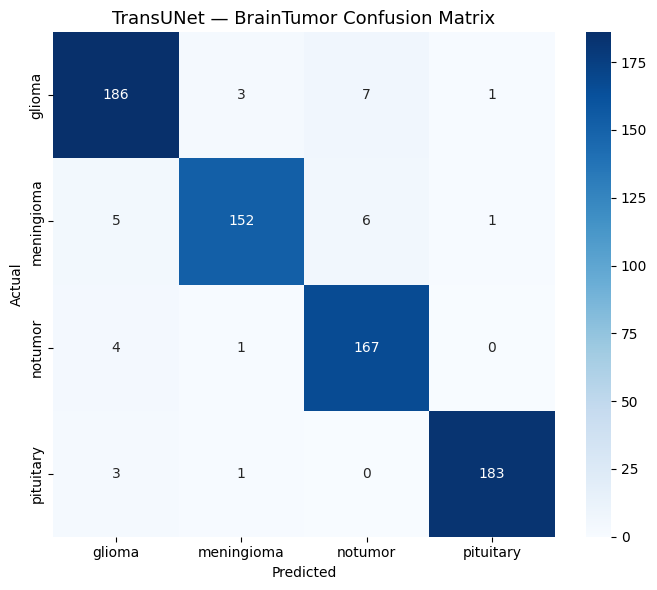

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/metric_images/transunet_confusion_matrix.png


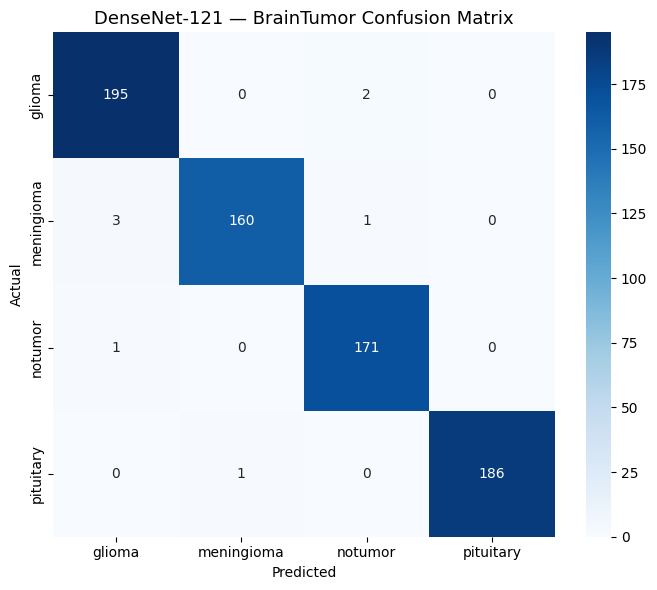

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/metric_images/densenet-121_confusion_matrix.png


In [ ]:
# Confusion matrices
plot_confusion_matrix(transunet_results)
plot_confusion_matrix(densenet_results)

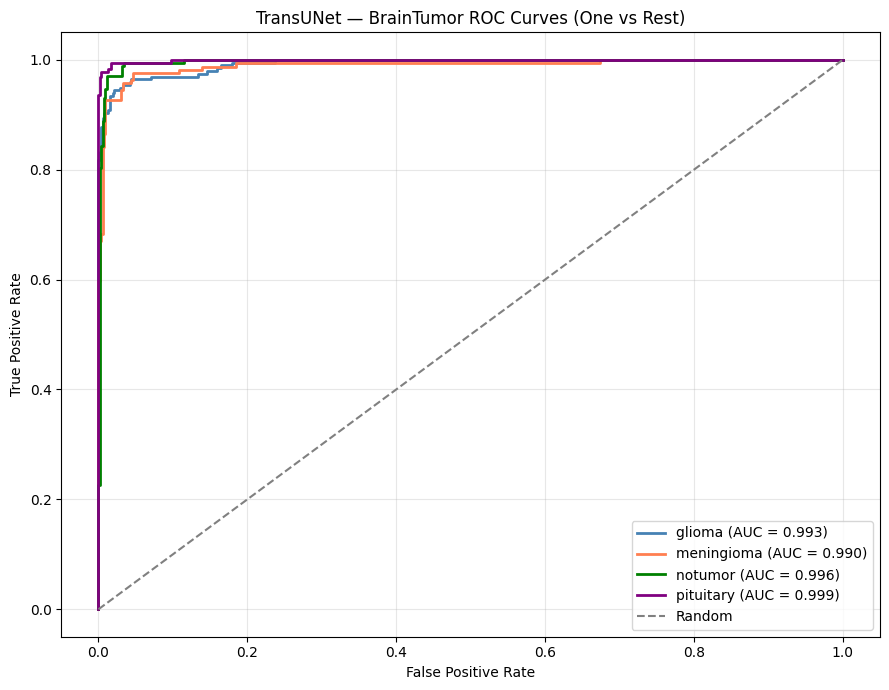

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/metric_images/transunet_roc_curve.png


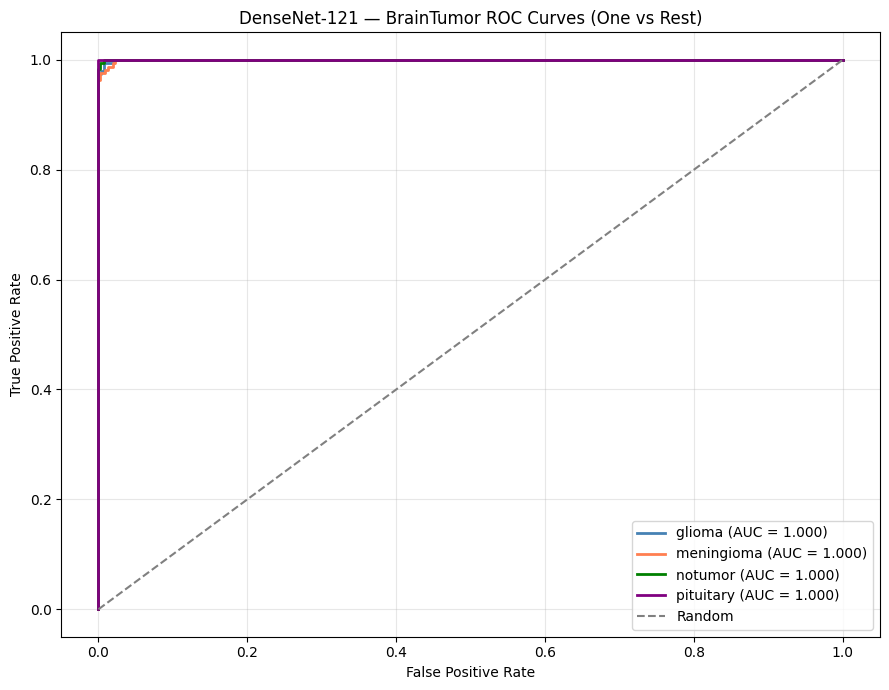

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/metric_images/densenet-121_roc_curve.png


In [ ]:
# ROC curves
plot_roc_curve(transunet_results)
plot_roc_curve(densenet_results)

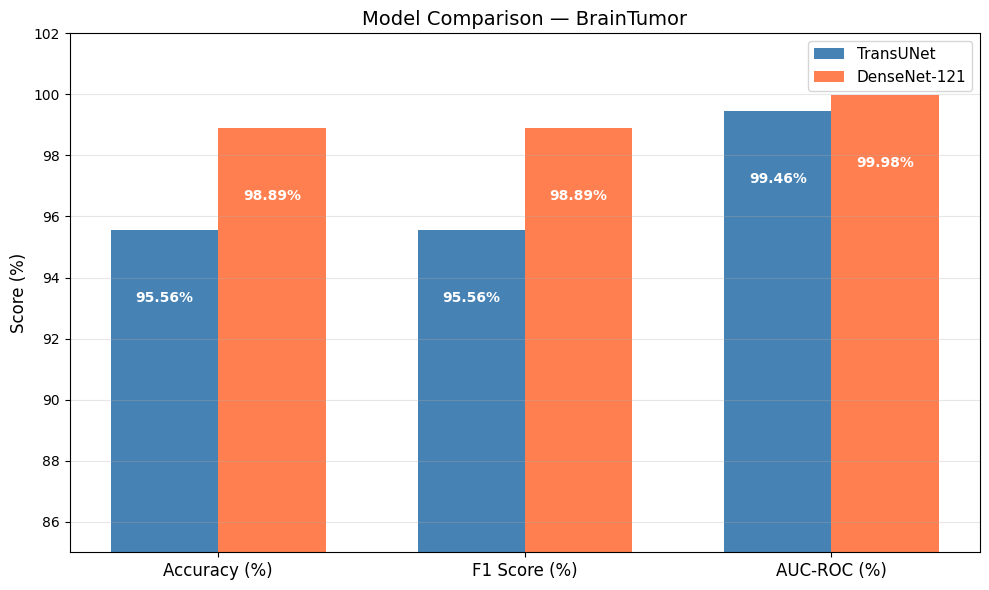

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/metric_images/comparison_chart.png


In [ ]:
# Side-by-side comparison
plot_comparison([transunet_results, densenet_results])

In [ ]:
# Final summary table
summary = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Accuracy (%)': f"{r['accuracy']:.2f}",
        'F1 Score (%)':  f"{r['f1']:.2f}",
        'AUC-ROC (%)':   f"{r['auc_roc']:.2f}",
    }
    for r in [transunet_results, densenet_results]
])
print(f'\n{DATASET_NAME} — Final Results')
print(summary.to_string(index=False))

summary_path = os.path.join(SAVE_DIR, f'{DATASET_NAME.lower()}_results_summary.csv')
summary.to_csv(summary_path, index=False)
print(f'\nSummary saved to: {summary_path}')


BrainTumor — Final Results
       Model Accuracy (%) F1 Score (%) AUC-ROC (%)
   TransUNet        95.56        95.56       99.46
DenseNet-121        98.89        98.89       99.98

Summary saved to: /content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/braintumor_results_summary.csv
